In [1]:
import os
import pandas as pd
import numpy as np
import datetime as dt
import math
from tqdm import tqdm

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-07 20:58:07.434515


#### Functions

In [3]:
def split_data(flt_prop_row):
    if flt_prop_row <= 0.60:
        return 'train'
    elif flt_prop_row <= 0.8:
        return 'test'
    else:
        return 'holdout'

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# subtask
str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

# get the dob
int_dob = 720
print(f'DOB: {int_dob}')

# logic
if int_dob == 720:
    str_target = 'Early_Pay_Delinquency_60_720_Flag'
else:
    pass
print(f'Target: {str_target}')

str_dirname_output = './output'

flt_thresh_train = 0.60

flt_thresh_test = 0.80

Project: 20241112-simple-model-test
Task: 20_60_in_720_bk_chargeoff
Subtask: 01_data_split
DOB: 720
Target: Early_Pay_Delinquency_60_720_Flag


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
%%time

str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_prep_data/{str_filename}'
df = pd.read_parquet(
    str_uri,
)

# get month of request
df['request_month'] = df['request_datetime'].apply(
    lambda x: f'{str(x)[:7]}-01',
)
df['request_month'] = pd.to_datetime(df['request_month']).dt.date
# sort
df.sort_values(by='request_datetime', ascending=True, inplace=True)

# rm too new
df = df[df['request_datetime'] < '2022-12-01'].copy()

# subset to bk
df = df[df['ENG-bk'] == 1].copy()

# show
df

CPU times: user 11.6 s, sys: 3.95 s, total: 15.5 s
Wall time: 6.07 s


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month
0,5702434,2021-07-26 16:29:29.3903686,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Iowa,Franchise,Iowa,True,...,0,7,NaN,1.311220,1,0,0,0,0.616667,2021-07-01
2,5713063,2021-07-26 16:48:39.3211104,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,4,NaN,1.587073,1,0,0,0,NaN,2021-07-01
5,5695635,2021-07-27 09:30:13.4737972,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Ohio,Franchise,Ohio,True,...,1,4,NaN,1.220735,1,0,0,0,0.546279,2021-07-01
6,5695635,2021-07-27 09:30:13.4737972,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Ohio,Franchise,Ohio,True,...,1,4,NaN,1.220735,1,0,0,0,0.546279,2021-07-01
7,5708693,2021-07-27 09:38:03.1324450,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Franchise,Illinois,True,...,0,3,0.097813,1.151003,1,1,1,0,1.000000,2021-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41689,6424228,2022-11-30 23:29:59+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,0,0,Nevada,Franchise,Nevada,True,...,1,4,NaN,1.224673,1,1,1,0,1.000000,2022-11-01
41691,6465819,2022-11-30 23:30:54+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,0,0,Minnesota,Franchise,Minnesota,False,...,1,3,NaN,1.245057,1,1,0,1,1.000000,2022-11-01
41690,6465819,2022-11-30 23:30:54+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Minnesota,Franchise,Minnesota,False,...,1,3,NaN,1.245057,1,1,0,1,1.000000,2022-11-01
41692,6450520,2022-11-30 23:33:56+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Illinois,Franchise,Wisconsin,True,...,0,-1,NaN,1.246665,1,0,0,0,0.416667,2022-11-01


#### Create target

Matplotlib is building the font cache; this may take a moment.


<Axes: ylabel='Frequency'>

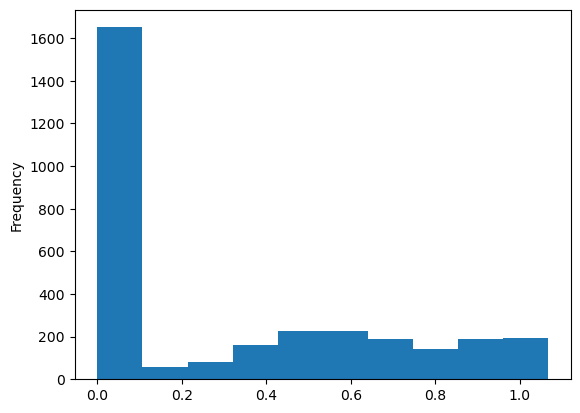

In [7]:
# get those that went delinquent
df = df[df[str_target] == 1].copy()
# clip
df[str_target] = df[f'loss_at_{int_dob}'].clip(lower=0)
# control for amt financed
df[str_target] = df[str_target] / df['amtfinanced__app']
# show
df[str_target].plot(kind='hist')

#### Remove too new from days on books (funded date - run date)

In [8]:
%%time

df = df[df['days_on_books'] >= int_dob].copy()
# show
df

CPU times: user 43.6 ms, sys: 58.4 ms, total: 102 ms
Wall time: 101 ms


,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-has_codebtor,ENG-vehicle_age,ENG-payment_to_income,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month
47,5713619,2021-07-28 09:42:35.0724058,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Colorado,Franchise,Colorado,True,...,1,3,NaN,1.238616,1,0,0,0,0.607317,2021-07-01
48,5713619,2021-07-28 09:42:35.0724058,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Colorado,Franchise,Colorado,True,...,1,3,NaN,1.238616,1,0,0,0,NaN,2021-07-01
74,5702366,2021-07-28 14:03:28.4109072,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Independent,Illinois,True,...,1,5,NaN,1.247092,1,0,0,0,0.051383,2021-07-01
75,5702366,2021-07-28 14:03:28.4109072,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Illinois,Independent,Illinois,True,...,1,5,0.078637,1.247092,1,1,1,0,1.000000,2021-07-01
78,5718084,2021-07-28 14:42:16.2851708,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Independent,Illinois,True,...,0,4,NaN,1.372926,1,0,0,1,0.862019,2021-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41660,6431771,2022-11-30 04:31:15+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Nevada,Franchise,Nevada,True,...,0,4,NaN,1.081820,1,0,0,0,NaN,2022-11-01
41665,6450589,2022-11-30 05:09:16+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Missouri,Franchise,Missouri,True,...,0,5,NaN,1.138750,1,0,0,0,0.766827,2022-11-01
41672,6398903,2022-11-30 06:03:29+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Arizona,Franchise,Arizona,False,...,0,2,NaN,1.195913,1,0,0,0,0.442509,2022-11-01
41675,6444851,2022-11-30 07:01:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Missouri,Franchise,Missouri,False,...,0,2,NaN,1.222964,1,0,0,0,0.107143,2022-11-01


#### Rm december

In [9]:
df = df[df['request_month'].astype(str) != '2022-12-01'].copy()

#### Split

In [10]:
df['row'] = range(1, df.shape[0] + 1)
df['prop_row'] = df['row'] / df.shape[0]

# split
df['data_set'] = df['prop_row'].apply(
    lambda x: split_data(x),
)
# show
df

,accountid,request_datetime,response_model_name,file_key,bitdebtor,bitdebtor__app,dealerstate__app,strdealershiptrackertype__app,strname__app,bitdealertrack__app,...,ENG-loan_to_value,ENG-bk,ENG-perfect_payment_hx,ENG-perfect_payment_hx_open,ENG-perfect_payment_hx_closed,ENG-bk_x_wtd_avg,request_month,row,prop_row,data_set
47,5713619,2021-07-28 09:42:35.0724058,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Colorado,Franchise,Colorado,True,...,1.238616,1,0,0,0,0.607317,2021-07-01,1,0.000321,train
48,5713619,2021-07-28 09:42:35.0724058,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Colorado,Franchise,Colorado,True,...,1.238616,1,0,0,0,NaN,2021-07-01,2,0.000641,train
74,5702366,2021-07-28 14:03:28.4109072,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Independent,Illinois,True,...,1.247092,1,0,0,0,0.051383,2021-07-01,3,0.000962,train
75,5702366,2021-07-28 14:03:28.4109072,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,0,0,Illinois,Independent,Illinois,True,...,1.247092,1,1,1,0,1.000000,2021-07-01,4,0.001282,train
78,5718084,2021-07-28 14:42:16.2851708,Gen10,deprecated/03_pull_payloads_tbldove/df_request...,1,1,Illinois,Independent,Illinois,True,...,1.372926,1,0,0,1,0.862019,2021-07-01,5,0.001603,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41660,6431771,2022-11-30 04:31:15+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Nevada,Franchise,Nevada,True,...,1.081820,1,0,0,0,NaN,2022-11-01,3115,0.998718,holdout
41665,6450589,2022-11-30 05:09:16+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Missouri,Franchise,Missouri,True,...,1.138750,1,0,0,0,0.766827,2022-11-01,3116,0.999038,holdout
41672,6398903,2022-11-30 06:03:29+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-29.gzip,1,1,Arizona,Franchise,Arizona,False,...,1.195913,1,0,0,0,0.442509,2022-11-01,3117,0.999359,holdout
41675,6444851,2022-11-30 07:01:46+00:00,PRESTIGE-GENXI,01_pull_payloads/df_requests_2022-11-30.gzip,1,1,Missouri,Franchise,Missouri,False,...,1.222964,1,0,0,0,0.107143,2022-11-01,3118,0.999679,holdout


#### Create tags

In [11]:
%%time

# train
df['train'] = df['data_set'].apply(
    lambda x: 1 if x == 'train' else 0,
)

CPU times: user 2.11 ms, sys: 0 ns, total: 2.11 ms
Wall time: 1.98 ms


In [12]:
%%time

# test
df['test'] = df['data_set'].apply(
    lambda x: 1 if x == 'test' else 0,
)

CPU times: user 2.78 ms, sys: 0 ns, total: 2.78 ms
Wall time: 2.43 ms


In [13]:
%%time

# holdout
df['holdout'] = df['data_set'].apply(
    lambda x: 1 if x == 'holdout' else 0,
)

CPU times: user 2.82 ms, sys: 0 ns, total: 2.82 ms
Wall time: 2.48 ms


#### Write to s3

In [14]:
list_str_filename = [
    'train',
    'test',
    'holdout',
]
for str_filename in tqdm(list_str_filename):
    print(f'Filename: {str_filename}')
    # subset
    df_tmp = df[df[str_filename] == 1].copy()
    # get n rows
    int_nrows = df_tmp.shape[0]
    print(f'Rows: {int_nrows}')
    print()
    # make column name
    df_tmp['data_set'] = str_filename
    # write
    str_filename_tmp = f'df_{str_filename}.gzip'
    str_uri = f's3://{str_project}/{str_task}/{str_subtask}/{str_filename_tmp}'
    df_tmp.to_parquet(str_uri, compression='gzip')

  0%|          | 0/3 [00:00<?, ?it/s]

Filename: train
Rows: 1871



 33%|███▎      | 1/3 [00:01<00:02,  1.27s/it]

Filename: test
Rows: 624



 67%|██████▋   | 2/3 [00:02<00:01,  1.02s/it]

Filename: holdout
Rows: 624



100%|██████████| 3/3 [00:02<00:00,  1.03it/s]
